# 00 : Chargement, observation & contrôle qualité

**Dataset.** Petit corpus d'incidents/arnaques cyber (contexte suisse), taxonomie réduite
(Fraude / Phishing / Malware)

Ce notebook : 
(1) charge et observe le dataset, 
(2) construit la taxonomie,
(3) cherche d'éventuelles **mauvaises catégorisations** 
Les exemples
suspects sont sauvés dans `artifacts/data_quality_flags.csv` pour revue manuelle.

In [1]:
import os, sys
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ollama

sns.set_theme(style="whitegrid", context="notebook")

import helpers as h
DEVICE = h.get_device()
os.makedirs("artifacts", exist_ok=True)

[device] using 'mps' (cuda=False, mps=True) | torch 2.11.0


## 1. Chargement & aperçu

In [2]:
# Diplay the first 20 examples

df, taxonomy_raw = h.load_m9()
df["_id"] = np.arange(len(df))            
print(f"{len(df)} exemples | colonnes: {list(df.columns)}")
df.head(20)

234 exemples | colonnes: ['text', 'language', 'lvl1', 'lvl2', 'lvl3', 'leaf_label', 'path', 'added_at', '_id']


,text,language,lvl1,lvl2,lvl3,leaf_label,path,added_at,_id
0,"A security check from ""Microsoft"" wanted me to...",en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,0
1,Call from a French speaking person telling me ...,en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,1
2,"Caller said he was from Microsoft, about a pro...",en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,2
3,Fake support calls from the spoofed numbers:\n...,en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,3
4,"Hello, around 15 employees received today arou...",en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,4
5,"Hello,The scammer used the following number: +...",en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,5
6,"Hi,\nI guy with an Indian accent called me and...",en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,6
7,I got a call from +41 78 933 96 98 offering me...,en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,7
8,I got a call from a woman saying that my compu...,en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,8
9,I received a call today from +44.1268.709.559 ...,en,Fraud,Fake-Support,Other-Fake-Support,Fraud/Fake-Support/Other-Fake-Support,"[Fraud, Fake-Support, Other-Fake-Support]",NaN,9


In [3]:
print("Langues:", df.language.value_counts().to_dict())
print("Catégories terminales:", df.leaf_label.nunique())
display(df.leaf_label.value_counts().rename("n").to_frame())

Langues: {'en': 234}
Catégories terminales: 13


,n
leaf_label,
Fraud/Fake-Support/Other-Fake-Support,18
Fraud/Fake-Support/Popup,18
Fraud/Fake-Sextortion/With-Password,18
Fraud/Fake-Sextortion/Other-Fake-Sextortion,18
Fraud/Investment-Fraud/Other-Investment-Fraud,18
Fraud/Investment-Fraud/Pig-Butchering,18
Phishing/Other-Phishing,18
Phishing/Parcel-Notification-Phishing,18
Phishing/Classified-Ad-Phishing,18


## 2. Équilibre, longueurs, profondeur

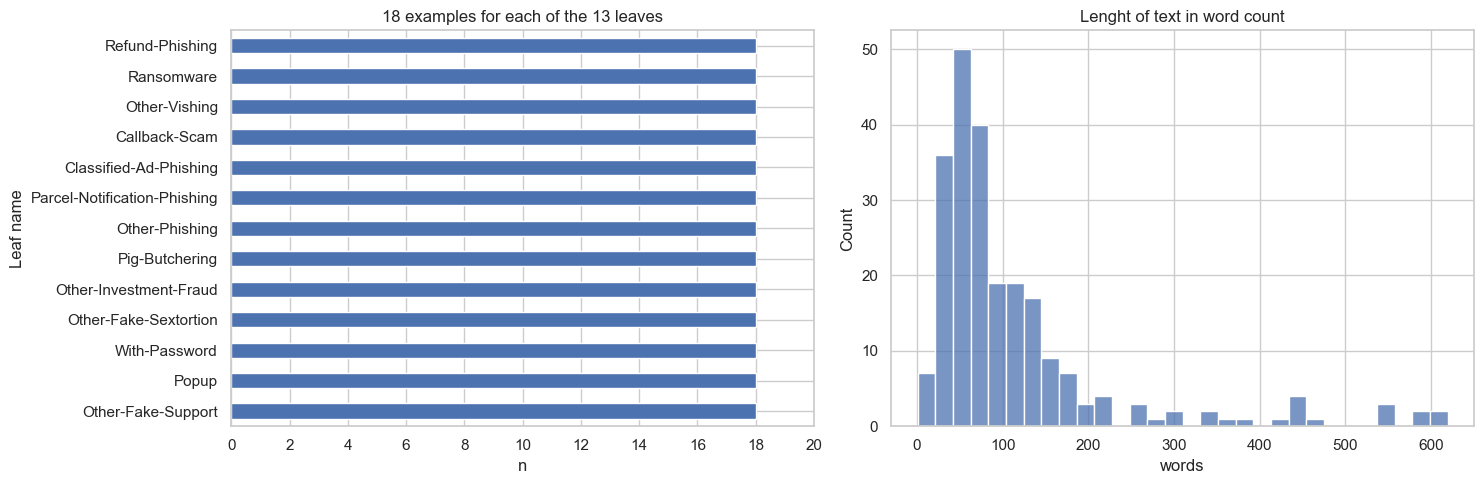

{'count': 234.0, 'mean': 114.5, 'std': 117.6, 'min': 1.0, '25%': 50.0, '50%': 72.0, '75%': 131.5, 'max': 619.0}


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
counts = df.leaf_label.value_counts().sort_values()
counts.index = counts.index.str.split("/").str[-1]   # "Phishing/Refund-Phishing" -> "Refund-Phishing"
counts.plot.barh(ax=ax[0])
nmax = int(counts.iloc[0])
xmax = nmax + 2
ax[0].set_title(f"{nmax} examples for each of the {df.leaf_label.nunique()} leaves")
ax[0].set_xlabel("n"); ax[0].set_ylabel("Leaf name")
ax[0].set_xlim(0, xmax); ax[0].set_xticks(range(0, xmax + 1, 2))

df["_len"] = df.text.str.split().str.len()
sns.histplot(df, x="_len", bins=30, ax=ax[1])
ax[1].set_title("Lenght of text in word count"); ax[1].set_xlabel("words")
plt.tight_layout(); plt.show()
print(df["_len"].describe().round(1).to_dict())

In [5]:
# Profondeur (terminal à depth 2 vs 3)
df["_depth"] = df.leaf_label.str.count("/") + 1
print("Profondeur des catégories terminales:")
print(df.groupby("_depth").leaf_label.nunique().rename("n_categories").to_frame())
print("\nExemples par profondeur:", df._depth.value_counts().to_dict())

Profondeur des catégories terminales:
        n_categories
_depth              
2                  5
3                  8

Exemples par profondeur: {3: 144, 2: 90}


## 3. Taxonomie (dérivée des chemins de feuilles)

In [6]:
tax = h.Taxonomy.from_leaves(df.leaf_label.unique())
print(f"n_nodes = {tax.n_nodes} | terminaux = {len(tax.terminals)}")
print("niveaux:", {d: len(v) for d, v in tax.levels.items()})
print()
def show_tree(node=tax.ROOT, indent=0):
    for child in tax.children[node]:
        tag = "  (terminal)" if tax.is_terminal(child) else ""
        print("    " * indent + "- " + child.split("/")[-1] + tag)
        show_tree(child, indent + 1)
show_tree()

n_nodes = 20 | terminaux = 13
niveaux: {1: 3, 2: 9, 3: 8}

- Fraud
    - Fake-Sextortion
        - Other-Fake-Sextortion  (terminal)
        - With-Password  (terminal)
    - Fake-Support
        - Other-Fake-Support  (terminal)
        - Popup  (terminal)
    - Investment-Fraud
        - Other-Investment-Fraud  (terminal)
        - Pig-Butchering  (terminal)
- Malware
    - Ransomware  (terminal)
- Phishing
    - Classified-Ad-Phishing  (terminal)
    - Other-Phishing  (terminal)
    - Parcel-Notification-Phishing  (terminal)
    - Refund-Phishing  (terminal)
    - Vishing
        - Callback-Scam  (terminal)
        - Other-Vishing  (terminal)


## 4. Contrôle qualité — détection de mauvaises catégorisations

On encode **tout** le dataset une fois (encodeur de phrases gelé) puis on cherche
les exemples suspects par trois angles complémentaires.

In [7]:
model, tok = h.load_encoder(device=DEVICE)
emb_all = h.cached_embeddings(df.text.tolist(),
                              cache_path="artifacts/emb_all.npy",
                              model=model, tok=tok, device=DEVICE)
print("embeddings:", emb_all.shape)

/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


embeddings: (234, 768)


In [8]:
# Désaccord k-NN : pour chaque exemple, la part de ses k plus proches voisins
# (cosinus) qui partagent SA feuille. Une part faible => exemple atypique / suspect.
from sklearn.neighbors import NearestNeighbors
K = 10
nn = NearestNeighbors(n_neighbors=K + 1, metric="cosine").fit(emb_all)
_, idx = nn.kneighbors(emb_all)
leaves = df.leaf_label.to_numpy()
same = np.array([np.mean(leaves[idx[i, 1:]] == leaves[i]) for i in range(len(df))])
df["knn_agreement"] = same
print("Agreement k-NN — plus bas = plus suspect:")
display(df.nsmallest(12, "knn_agreement")[["_id", "leaf_label", "knn_agreement", "_len"]])

Agreement k-NN — plus bas = plus suspect:


,_id,leaf_label,knn_agreement,_len
20,20,Fraud/Fake-Sextortion/With-Password,0.0,580
35,35,Fraud/Fake-Sextortion/Other-Fake-Sextortion,0.0,36
54,54,Fraud/Investment-Fraud/Other-Investment-Fraud,0.0,306
57,57,Fraud/Investment-Fraud/Other-Investment-Fraud,0.0,40
84,84,Malware/Ransomware,0.0,339
170,170,Phishing/Parcel-Notification-Phishing,0.0,43
30,30,Fraud/Fake-Sextortion/Other-Fake-Sextortion,0.1,619
34,34,Fraud/Fake-Sextortion/Other-Fake-Sextortion,0.1,29
42,42,Fraud/Investment-Fraud/Other-Investment-Fraud,0.1,446
63,63,Phishing/Parcel-Notification-Phishing,0.1,148


In [9]:
# Auto-confiance en cross-validation : un LogReg prédit chaque exemple en CV ;
# on signale ceux où la prédiction != vraie feuille AVEC forte confiance
# (style confident-learning : souvent ambigus ou mal étiquetés).
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
proba = cross_val_predict(clf, emb_all, leaves, cv=5, method="predict_proba")
classes = np.array(sorted(set(leaves)))
pred = classes[proba.argmax(1)]
conf = proba.max(1)
flagged = df.copy()
flagged["cv_pred"] = pred
flagged["cv_conf"] = conf
susp = flagged[(pred != leaves)].sort_values("cv_conf", ascending=False)
print(f"{len(susp)} exemples mal prédits en CV ; top par confiance (les plus suspects):")
display(susp.head(12)[["_id", "leaf_label", "cv_pred", "cv_conf"]])

53 exemples mal prédits en CV ; top par confiance (les plus suspects):


,_id,leaf_label,cv_pred,cv_conf
55,55,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,0.247905
49,49,Fraud/Investment-Fraud/Pig-Butchering,Fraud/Investment-Fraud/Other-Investment-Fraud,0.242203
122,122,Phishing/Vishing/Callback-Scam,Phishing/Refund-Phishing,0.241624
56,56,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,0.225464
132,132,Phishing/Vishing/Callback-Scam,Phishing/Other-Phishing,0.217544
57,57,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Fake-Support/Other-Fake-Support,0.216633
125,125,Phishing/Vishing/Callback-Scam,Phishing/Refund-Phishing,0.215973
20,20,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,0.213001
175,175,Phishing/Other-Phishing,Phishing/Refund-Phishing,0.201157
180,180,Phishing/Other-Phishing,Phishing/Parcel-Notification-Phishing,0.197902


In [10]:
# Consolide les exemples suspects et sauvegarde pour revue manuelle.
flags = df[["_id", "leaf_label", "text", "knn_agreement"]].copy()
flags["cv_pred"] = pred
flags["cv_conf"] = conf
flags["_len"] = df["_len"].to_numpy()          # carry word count for audit
flags["suspect_knn"] = flags.knn_agreement < 0.3
flags["suspect_cv"] = (pred != leaves) & (conf > 0.6)
flags["suspect_len"] = flags["_len"] < 5  # Short text
flags["suspect"] = flags.suspect_knn | flags.suspect_cv | flags.suspect_len
flags.to_csv("artifacts/data_quality_flags.csv", index=False)
print(f"{flags.suspect.sum()} exemples signalés -> artifacts/data_quality_flags.csv")
display(flags[flags.suspect].sort_values("knn_agreement")
        .head(15)[["_id", "leaf_label", "cv_pred", "cv_conf", "knn_agreement", "_len"]])

34 exemples signalés -> artifacts/data_quality_flags.csv


,_id,leaf_label,cv_pred,cv_conf,knn_agreement,_len
84,84,Malware/Ransomware,Fraud/Fake-Sextortion/Other-Fake-Sextortion,0.128263,0.0,339
20,20,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,0.213001,0.0,580
170,170,Phishing/Parcel-Notification-Phishing,Phishing/Refund-Phishing,0.142780,0.0,43
35,35,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Fake-Sextortion/With-Password,0.102666,0.0,36
54,54,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Other-Investment-Fraud,0.118773,0.0,306
57,57,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Fake-Support/Other-Fake-Support,0.216633,0.0,40
180,180,Phishing/Other-Phishing,Phishing/Parcel-Notification-Phishing,0.197902,0.1,78
179,179,Phishing/Other-Phishing,Phishing/Other-Phishing,0.161517,0.1,139
175,175,Phishing/Other-Phishing,Phishing/Refund-Phishing,0.201157,0.1,130
168,168,Phishing/Parcel-Notification-Phishing,Phishing/Other-Phishing,0.153584,0.1,1


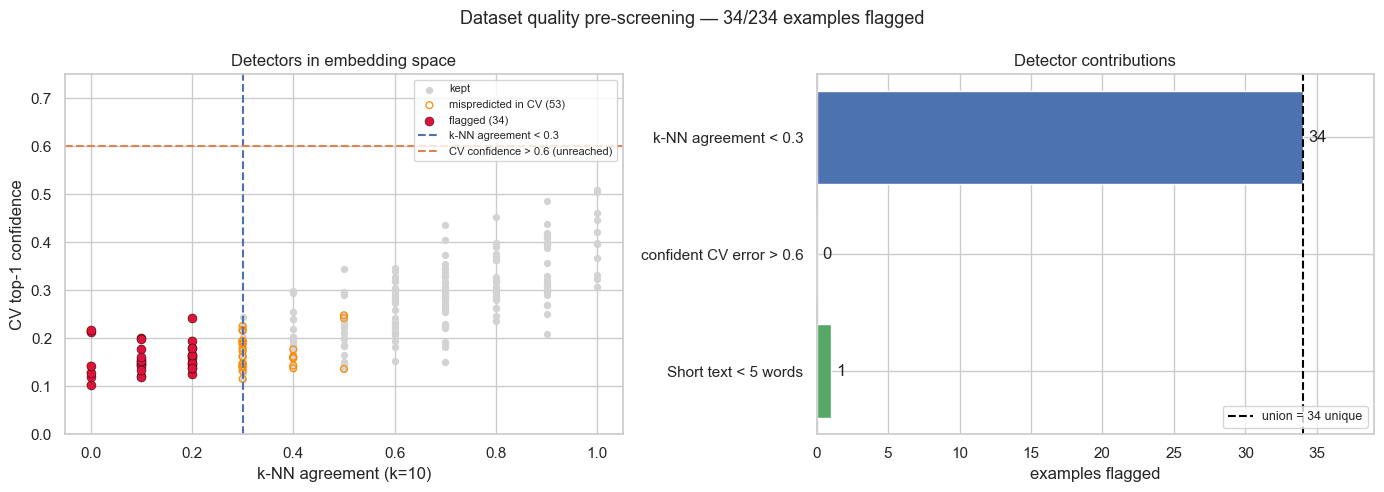

saved -> artifacts/images_rapport/data_quality_detectors.png  (kNN=34, CV=0, len=1, union=34/234; CV mispredictions=53, none confident)


In [11]:
# Report figure: result of the 3 data-quality detectors (k-NN agreement, confident CV error,
# Short text). Self-contained — reloads artifacts/data_quality_flags.csv produced above.

import os
import pandas as pd
import matplotlib.pyplot as plt

qc = pd.read_csv("artifacts/data_quality_flags.csv")
n_total, n_flagged = len(qc), int(qc["suspect"].sum())
mispred = qc[qc["cv_pred"] != qc["leaf_label"]]   # mispredicted in CV, at any confidence

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# (A) Embedding space: k-NN agreement (x) vs CV top-1 confidence (y), both thresholds drawn.
# The whole cloud (max conf 0.51) sits below 0.6, so the CV detector flags none of the 53 misses.
ax[0].scatter(qc["knn_agreement"], qc["cv_conf"], s=18, c="lightgray", label="kept")
ax[0].scatter(mispred["knn_agreement"], mispred["cv_conf"], s=24,
              facecolor="none", edgecolor="darkorange", linewidth=0.9,
              label=f"mispredicted in CV ({len(mispred)})")
ax[0].scatter(qc[qc["suspect"]]["knn_agreement"], qc[qc["suspect"]]["cv_conf"], s=42,
              c="crimson", edgecolor="black", linewidth=0.3, label=f"flagged ({n_flagged})")
ax[0].axvline(0.3, ls="--", c="#4C72B0", label="k-NN agreement < 0.3")
ax[0].axhline(0.6, ls="--", c="#DD8452", label="CV confidence > 0.6 (unreached)")
ax[0].set_ylim(0, 0.75)
ax[0].set_xlabel("k-NN agreement (k=10)")
ax[0].set_ylabel("CV top-1 confidence")
ax[0].set_title("Detectors in embedding space")
ax[0].legend(loc="upper right", fontsize=8)

# (B) How many examples each detector flags (overlapping sets) + the union total.
det = {"k-NN agreement < 0.3": int(qc["suspect_knn"].sum()),
       "confident CV error > 0.6": int(qc["suspect_cv"].sum()),
       "Short text < 5 words": int(qc["suspect_len"].sum())}
bars = ax[1].barh(list(det), list(det.values()),
                  color=["#4C72B0", "#DD8452", "#55A868"])
ax[1].bar_label(bars, padding=4)
ax[1].axvline(n_flagged, ls="--", c="black", label=f"union = {n_flagged} unique")
ax[1].set_xlim(0, n_flagged + 5)
ax[1].set_xlabel("examples flagged")
ax[1].set_title("Detector contributions")
ax[1].invert_yaxis()
ax[1].legend(loc="lower right", fontsize=9)

fig.suptitle(f"Dataset quality pre-screening — {n_flagged}/{n_total} examples flagged", fontsize=13)
plt.tight_layout()

os.makedirs("artifacts/images_rapport", exist_ok=True)
out = "artifacts/images_rapport/data_quality_detectors.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved -> {out}  "
      f"(kNN={det['k-NN agreement < 0.3']}, CV={det['confident CV error > 0.6']}, "
      f"len={det['Short text < 5 words']}, union={n_flagged}/{n_total}; "
      f"CV mispredictions={len(mispred)}, none confident)")

In [12]:
# Quasi-doublons inter-catégories : paires très similaires (cosinus > 0.95)
# dont les feuilles diffèrent => incohérence d'étiquetage potentielle.
from sklearn.metrics.pairwise import cosine_similarity
S = cosine_similarity(emb_all)
np.fill_diagonal(S, 0.0)
pairs = []
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if S[i, j] > 0.95 and leaves[i] != leaves[j]:
            pairs.append((i, j, round(float(S[i, j]), 3), leaves[i], leaves[j]))
dup = pd.DataFrame(pairs, columns=["i", "j", "cos", "leaf_i", "leaf_j"]).sort_values("cos", ascending=False)
print(f"{len(dup)} paires quasi-identiques de feuilles différentes:")
display(dup.head(12))

0 paires quasi-identiques de feuilles différentes:


,i,j,cos,leaf_i,leaf_j


# Fenêtre de contexte de l'encodeur

In [13]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(h.ENCODER_NAME)
df["_tokens"] = [len(tok.encode(t)) for t in df.text]

trunc = df._tokens > 128
print(f"Tokens: {df._tokens.describe().round(1).to_dict()}")
print(f"Tronqués à 128 tokens: {trunc.sum()}/{len(df)} ({trunc.mean():.0%})")
print(f"Ratio tokens/mots médian: {(df._tokens / df._len.clip(lower=1)).median():.2f}")
print("\nTaux de troncature par feuille:")
display(df.groupby("leaf_label")._tokens.apply(lambda s: (s > 128).mean())
        .sort_values(ascending=False).rename("part_tronquée").to_frame())

Token indices sequence length is longer than the specified maximum sequence length for this model (873 > 512). Running this sequence through the model will result in indexing errors


Tokens: {'count': 234.0, 'mean': 184.9, 'std': 235.1, 'min': 18.0, '25%': 70.0, '50%': 109.0, '75%': 192.8, 'max': 2121.0}
Tronqués à 128 tokens: 103/234 (44%)
Ratio tokens/mots médian: 1.42

Taux de troncature par feuille:


,part_tronquée
leaf_label,
Phishing/Refund-Phishing,0.777778
Phishing/Classified-Ad-Phishing,0.611111
Fraud/Fake-Sextortion/With-Password,0.555556
Phishing/Parcel-Notification-Phishing,0.555556
Fraud/Investment-Fraud/Other-Investment-Fraud,0.500000
Phishing/Other-Phishing,0.500000
Fraud/Fake-Sextortion/Other-Fake-Sextortion,0.444444
Fraud/Fake-Support/Popup,0.444444
Fraud/Investment-Fraud/Pig-Butchering,0.444444


_Sonde linéaire (Silla & Freitas 2011) : régression logistique multinomiale sur les embeddings gelés, prédisant la feuille._

In [14]:
def fit_flat(emb_train, leaves_train, seed=0):
    """Fit a multinomial LogReg on frozen embeddings, predicting the leaf."""
    from sklearn.linear_model import LogisticRegression

    clf = LogisticRegression(max_iter=2000, random_state=seed, class_weight="balanced")
    clf.fit(emb_train, list(leaves_train))
    return clf


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


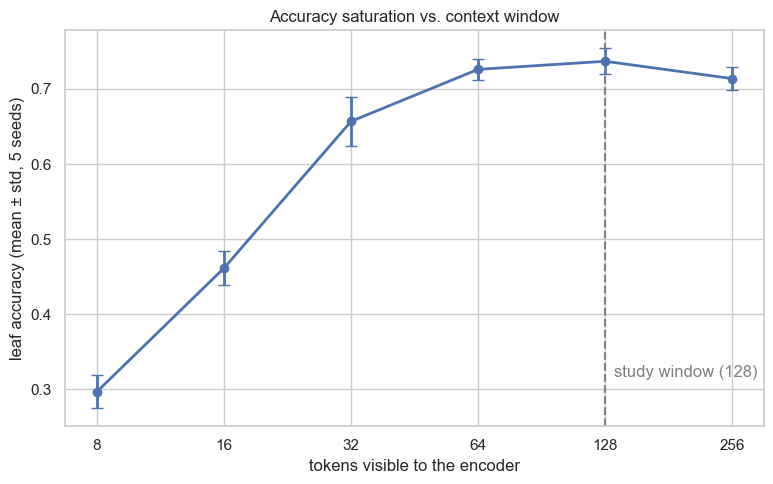

   8 tokens : 0.297 ± 0.022
  16 tokens : 0.462 ± 0.023
  32 tokens : 0.657 ± 0.033
  64 tokens : 0.726 ± 0.014
 128 tokens : 0.737 ± 0.017
 256 tokens : 0.714 ± 0.015

Δ(256 - 128) = -0.023  -> if ≈ 0: doubling the window gains nothing, 128 is justified.
st.max_seq_length restored to study window: 128


In [15]:
splits = h.make_balanced_splits(df, seeds=h.SEEDS)
st = h.st_model(h.ENCODER_NAME, device=DEVICE)
windows = [8, 16, 32, 64, 128, 256]
acc = {w: [] for w in windows}

for w in windows:
    st.max_seq_length = w
    emb_w = st.encode(df.text.tolist(), normalize_embeddings=True,
                      convert_to_numpy=True, show_progress_bar=False)
    for seed in h.SEEDS:
        tr, te = splits[seed]["train"], splits[seed]["test"]
        clf = fit_flat(emb_w[tr._id.values], tr.leaf_label, seed=seed)
        acc[w].append((clf.predict(emb_w[te._id.values]) == te.leaf_label.values).mean())

m = np.array([np.mean(acc[w]) for w in windows])
s = np.array([np.std(acc[w]) for w in windows])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(windows, m, yerr=s, marker="o", capsize=4, lw=2)
ax.axvline(128, ls="--", c="gray")
ax.text(134, m.min() + 0.02, "study window (128)", c="gray")
ax.set_xscale("log", base=2)
ax.set_xticks(windows); ax.set_xticklabels(windows)
ax.set_xlabel("tokens visible to the encoder")
ax.set_ylabel("leaf accuracy (mean ± std, 5 seeds)")
ax.set_title("Accuracy saturation vs. context window")
plt.tight_layout(); plt.show()

for w in windows:
    print(f"{w:>4} tokens : {np.mean(acc[w]):.3f} ± {np.std(acc[w]):.3f}")
print(f"\nΔ(256 - 128) = {np.mean(acc[256]) - np.mean(acc[128]):+.3f}"
      "  -> if ≈ 0: doubling the window gains nothing, 128 is justified.")

st.max_seq_length = h.MAX_LENGTH
print(f"st.max_seq_length restored to study window: {st.max_seq_length}")